Saving ikann.jpg to ikann.jpg
Kelas yang diprediksi: 395
Nama kelas: garfish


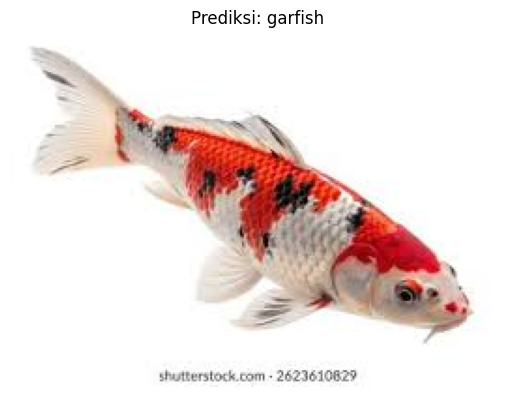


Top 5 Prediksi:
1. garfish - 71.71%
2. banded gecko - 5.91%
3. goldfish - 4.87%
4. snoek - 3.60%
5. kingsnake - 1.67%

Shape Tensor: torch.Size([3, 224, 224])
Dtype Tensor: torch.float32


In [ ]:
# Install dan import library
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json
import requests

from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file otomatis
file_name = list(uploaded.keys())[0]

# Load model pretrained ResNet18
model = models.resnet18(pretrained=True)
model.eval()

# Transformasi gambar
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Membaca gambar
img = Image.open(file_name)

# Transform gambar
img_t = transform(img)

# Tambahkan batch dimension
batch_t = img_t.unsqueeze(0)

# Inferensi
out = model(batch_t)

# Prediksi kelas tertinggi
_, predicted = torch.max(out, 1)

# Download label ImageNet
labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"

response = requests.get(labels_url)
imagenet_labels = response.json()

# Nama kelas hasil prediksi
predicted_class_name = imagenet_labels[predicted.item()]

# Tampilkan hasil prediksi
print("Kelas yang diprediksi:", predicted.item())
print("Nama kelas:", predicted_class_name)

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class_name}")
plt.show()

# Top 5 prediksi
probabilities = F.softmax(out[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\nTop 5 Prediksi:")
for i in range(top5_prob.size(0)):
    print(
        f"{i+1}. "
        f"{imagenet_labels[top5_catid[i]]} "
        f"- {top5_prob[i].item()*100:.2f}%"
    )

# Shape dan dtype
print("\nShape Tensor:", img_t.shape)
print("Dtype Tensor:", img_t.dtype)